# 03 Predictive Modeling

## Project Context
This notebook builds churn prediction models for a Netflix-like streaming customer dataset.

## Objectives
- Prepare numeric and categorical features using a reproducible preprocessing pipeline
- Train an interpretable Logistic Regression baseline
- Train a Random Forest comparison model
- Evaluate performance with accuracy, precision, recall, F1, ROC-AUC, and confusion matrices
- Identify the strongest churn drivers for retention planning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

## 1. Load the Cleaned Dataset

In [2]:
data_path = "../data/processed/netflix_churn_cleaned.csv"
df_model = pd.read_csv(data_path)

df_model.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## 2. Prepare Features and Target

The target is `churned`. All remaining columns are used as predictors. Preprocessing is fit only on the training data through scikit-learn pipelines.

In [3]:
target = "churned"
X = df_model.drop(columns=[target])
y = df_model[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target distribution:")
print(y.value_counts(normalize=True).sort_index())

Numeric features: ['age', 'watch_hours', 'last_login_days', 'monthly_fee', 'number_of_profiles', 'avg_watch_time_per_day']
Categorical features: ['gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
Target distribution:
churned
0    0.497
1    0.503
Name: proportion, dtype: float64


## 3. Train-Test Split

The split is stratified to keep the churn ratio stable in both training and test sets.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train churn rate:", round(y_train.mean(), 3))
print("y_test churn rate:", round(y_test.mean(), 3))

X_train shape: (4000, 12)
X_test shape: (1000, 12)
y_train churn rate: 0.503
y_test churn rate: 0.503


## 4. Build Preprocessing Pipelines

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## 5. Baseline Model: Logistic Regression

Logistic Regression is used as the interpretable baseline model.

In [6]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

logistic_pipeline.fit(X_train, y_train)
logistic_predictions = logistic_pipeline.predict(X_test)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)[:, 1]

Logistic Regression Accuracy: 0.888
Logistic Regression ROC-AUC: 0.9665

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       497
           1       0.87      0.91      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



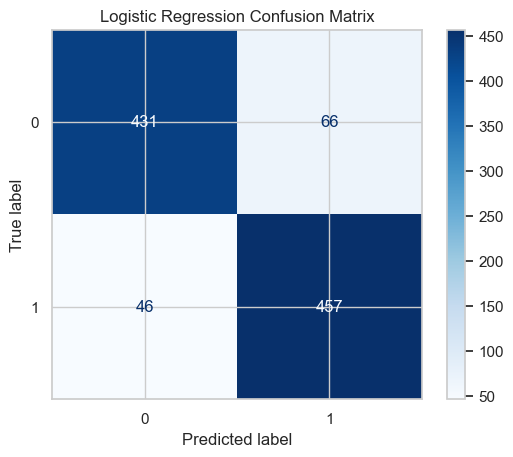

In [7]:
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, logistic_predictions), 4))
print("Logistic Regression ROC-AUC:", round(roc_auc_score(y_test, logistic_probabilities), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, logistic_predictions))

ConfusionMatrixDisplay.from_predictions(y_test, logistic_predictions, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 6. Logistic Regression Feature Importance

Coefficient magnitude shows which features have the strongest relationship with churn after preprocessing.

In [8]:
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = logistic_pipeline.named_steps["model"].coef_[0]

logistic_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients),
}).sort_values("absolute_coefficient", ascending=False)

logistic_importance.head(15)

,feature,coefficient,absolute_coefficient
5,num__avg_watch_time_per_day,-4.272757,4.272757
1,num__watch_hours,-3.583103,3.583103
2,num__last_login_days,2.280181,2.280181
19,cat__payment_method_Crypto,1.614807,1.614807
21,cat__payment_method_Gift Card,1.471635,1.471635
4,num__number_of_profiles,-1.136400,1.136400
9,cat__subscription_type_Standard,-1.048867,1.048867
3,num__monthly_fee,-0.825388,0.825388
24,cat__favorite_genre_Documentary,-0.298814,0.298814
20,cat__payment_method_Debit Card,-0.287181,0.287181


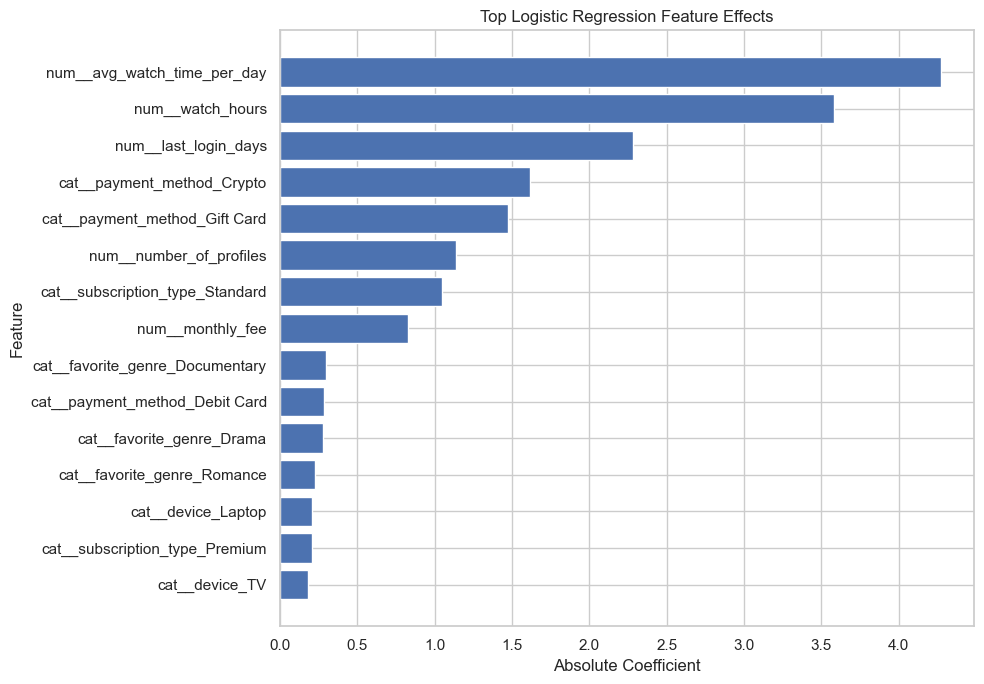

In [9]:
top_logistic_features = logistic_importance.head(15).sort_values("absolute_coefficient")

plt.figure(figsize=(10, 7))
plt.barh(top_logistic_features["feature"], top_logistic_features["absolute_coefficient"])
plt.title("Top Logistic Regression Feature Effects")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. Comparison Model: Random Forest

Random Forest can capture non-linear relationships and interactions between behavior, subscription, and demographic features.

In [10]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
        ]), categorical_features),
    ]
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

random_forest_pipeline.fit(X_train, y_train)
rf_predictions = random_forest_pipeline.predict(X_test)
rf_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

Random Forest Accuracy: 0.98
Random Forest ROC-AUC: 0.9971

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       497
           1       0.98      0.98      0.98       503

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



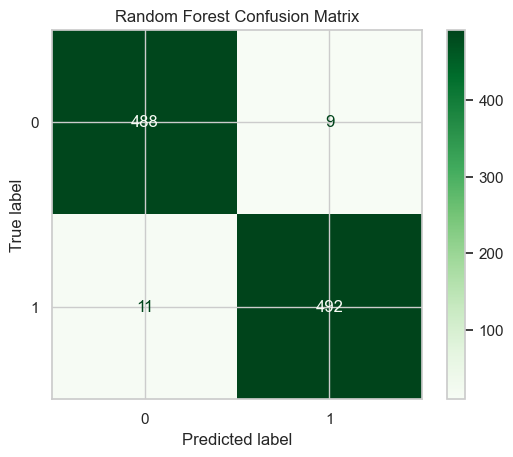

In [11]:
print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_predictions), 4))
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_probabilities), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, rf_predictions))

ConfusionMatrixDisplay.from_predictions(y_test, rf_predictions, cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.show()

## 8. Cross-Validation Check

Cross-validation helps confirm that the high test score is not only caused by a lucky train-test split.

In [12]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_results = cross_validate(
    random_forest_pipeline,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
)

pd.DataFrame({
    metric.replace("test_", ""): [scores.mean(), scores.std()]
    for metric, scores in cv_results.items()
    if metric.startswith("test_")
}, index=["mean", "std"]).T.sort_index()

,mean,std
accuracy,0.975600,0.003007
f1,0.975534,0.003148
precision,0.983502,0.005139
recall,0.967793,0.009443
roc_auc,0.997239,0.000641


## 9. Random Forest Feature Importance

In [13]:
rf_feature_names = random_forest_pipeline.named_steps["preprocessor"].get_feature_names_out()
rf_importances = random_forest_pipeline.named_steps["model"].feature_importances_

rf_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_importances,
}).sort_values("importance", ascending=False)

rf_importance.head(15)

,feature,importance
5,num__avg_watch_time_per_day,0.397609
1,num__watch_hours,0.210932
2,num__last_login_days,0.188522
4,num__number_of_profiles,0.063633
3,num__monthly_fee,0.027866
0,num__age,0.017047
19,cat__payment_method_Crypto,0.016098
21,cat__payment_method_Gift Card,0.013941
8,cat__subscription_type_Premium,0.007939
9,cat__subscription_type_Standard,0.007883


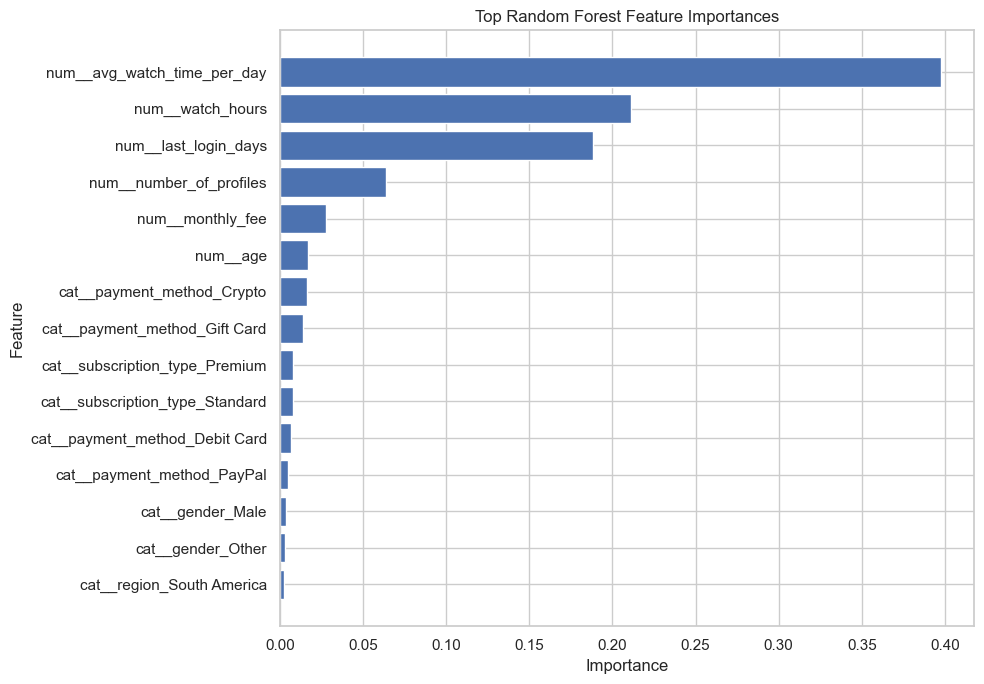

In [14]:
top_rf_features = rf_importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_rf_features["feature"], top_rf_features["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Model Summary

Both models support the same business conclusion: engagement and inactivity are the strongest churn signals. Logistic Regression is easier to explain, while Random Forest captures more complex patterns and provides stronger predictive performance. For retention planning, the model should be used to prioritize users for outreach, not as the only decision rule.